# Notebook 3: Predictive Evaluation and Final Results

## Project: Beyond Distributional Similarity — Evaluating Predictive Utility of Synthetic Liver Cirrhosis Data

**Dataset:** Mayo Clinic Primary Biliary Cirrhosis (PBC) Trial  
**Author:** Michael Udousoro

---

## What this notebook covers

Distributional fidelity metrics like FID tell us whether synthetic data looks statistically similar to real data. They do not tell us whether adding synthetic data to a training set actually improves a model's ability to predict patient outcomes. This notebook answers that more clinically meaningful question.

We train three classifiers under three training scenarios and evaluate all of them on the same held-out real test set. The comparison shows whether synthetic augmentation — using either the best individual generator (CTGAN) or the multi-method consensus set — leads to better predictions than training on real data alone.

This is the central result of the paper.

---

## Training scenarios

| Scenario | Training data | Purpose |
|---|---|---|
| A: Baseline | 193 real patients only | Reference point with no augmentation |
| B: Real plus CTGAN | 193 real + filtered CTGAN records | Best individual generator (lowest FID) |
| C: Real plus Consensus | 193 real + consensus records | Multi-method high-confidence augmentation |

The test set is always the 83 held-out real patients. It is never augmented.

---

## Prerequisites

Run Notebooks 1 and 2 first. This notebook loads data saved to `output/data/` by the previous notebooks.

---

## Outputs saved by this notebook

- `output/results/model_performance.csv` — accuracy, F1, precision, recall, AUC for every scenario and classifier  
- `output/results/summary_report.txt` — plain-text report collecting all key results in one place  
- `output/figures/fig6` through `fig9` — performance heatmap, model comparison bar chart, all-metrics line plot, pipeline flowchart

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())

from src.data_loader         import TARGET_COL, ALL_FEATURE_COLS
from src.predictive_modeling import run_all_scenarios, pivot_results
from src.visualizations      import (
    plot_performance_heatmap, plot_model_comparison,
    plot_all_metrics, plot_pipeline_flowchart
)

os.makedirs('output/results', exist_ok=True)
os.makedirs('output/figures', exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


---

## Section 1: Loading All Required Data

We load the real train and test sets from Notebook 1, and the filtered CTGAN and consensus synthetic datasets from Notebook 2.

In [2]:
train_df       = pd.read_csv('output/data/train_real.csv')
test_df        = pd.read_csv('output/data/test_real.csv')
filtered_ctgan = pd.read_csv('output/data/filtered_ctgan.csv')
consensus_df   = pd.read_csv('output/data/consensus.csv')
fid_df         = pd.read_csv('output/results/fid_scores.csv')
iqr_summary    = pd.read_csv('output/results/iqr_filter_summary.csv')
consensus_summary = pd.read_csv('output/results/consensus_summary.csv')

# Load statistical results
stats = {}
for name in ['shapiro_wilk', 'ks_tests', 'js_divergence', 'cohens_d', 'chi_square']:
    path = f'output/results/stats_{name}.csv'
    if os.path.exists(path):
        stats[name] = pd.read_csv(path)

print(f'Training set:          {len(train_df)} real patients')
print(f'Test set:              {len(test_df)} real patients (held out)')
print(f'Filtered CTGAN:        {len(filtered_ctgan)} synthetic records')
print(f'Consensus set:         {len(consensus_df)} synthetic records')

Training set:          193 real patients
Test set:              83 real patients (held out)
Filtered CTGAN:        210 synthetic records
Consensus set:         782 synthetic records


---

## Section 2: Running the Classification Experiments

Three classifiers are trained under each scenario:

- **Random Forest** (200 decision trees) — robust to feature correlations and non-linear relationships, good baseline for tabular data
- **Gradient Boosting** (200 estimators, max depth 3) — typically the strongest performer on small structured datasets
- **Logistic Regression** — linear classifier, interpretable, useful for understanding feature contributions

For each scenario, the scaler is fitted on that scenario's training data and applied to the test set. This ensures the test set is always scaled according to the distribution of whatever data was used for training, which is the methodologically correct approach.

In [3]:
performance_df = run_all_scenarios(train_df, test_df, filtered_ctgan, consensus_df)
performance_df.to_csv('output/results/model_performance.csv', index=False)

print('Classification results saved.')


  Scenario: A: Baseline (real data only)
  Training set size: 193  |  Test set size: 83
    Random Forest           Accuracy 0.7831  F1 0.7848  AUC 0.8479
    Gradient Boosting       Accuracy 0.7831  F1 0.7852  AUC 0.8776
    Logistic Regression     Accuracy 0.7711  F1 0.7735  AUC 0.8291

  Scenario: B: Real data plus filtered CTGAN
  Training set size: 403  |  Test set size: 83
    Random Forest           Accuracy 0.7590  F1 0.7616  AUC 0.8418
    Gradient Boosting       Accuracy 0.7590  F1 0.7616  AUC 0.8721
    Logistic Regression     Accuracy 0.7590  F1 0.7616  AUC 0.8455

  Scenario: C: Real data plus consensus synthetic
  Training set size: 975  |  Test set size: 83
    Random Forest           Accuracy 0.7831  F1 0.7841  AUC 0.8539
    Gradient Boosting       Accuracy 0.7349  F1 0.7377  AUC 0.8321
    Logistic Regression     Accuracy 0.7711  F1 0.7731  AUC 0.8552
Classification results saved.


---

## Section 3: Results — F1 Score Summary

The F1 score balances precision and recall. We use the weighted F1 score, which accounts for the class imbalance in the test set by weighting each class's F1 score by its proportion in the test data.

In [4]:
print('F1 scores by scenario and classifier:')
print()
pivot_results(performance_df, 'F1')

F1 scores by scenario and classifier:



Classifier,Gradient Boosting,Logistic Regression,Random Forest
Scenario,,,
A: Baseline (real data only),0.7852,0.7735,0.7848
B: Real data plus filtered CTGAN,0.7616,0.7616,0.7616
C: Real data plus consensus synthetic,0.7377,0.7731,0.7841


## Section 4: Results — Full Performance Table

The full table shows accuracy, F1, precision, recall, and AUC for every combination of scenario and classifier. AUC (area under the ROC curve) measures how well the classifier separates the two outcome classes regardless of the classification threshold.

In [5]:
print('Full performance results:')
print()
display_cols = ['Scenario', 'Classifier', 'Accuracy', 'F1', 'Precision', 'Recall', 'AUC']
performance_df[display_cols].round(4)

Full performance results:



,Scenario,Classifier,Accuracy,F1,Precision,Recall,AUC
0,A: Baseline (real data only),Random Forest,0.7831,0.7848,0.7901,0.7831,0.8479
1,A: Baseline (real data only),Gradient Boosting,0.7831,0.7852,0.7955,0.7831,0.8776
2,A: Baseline (real data only),Logistic Regression,0.7711,0.7735,0.7940,0.7711,0.8291
3,B: Real data plus filtered CTGAN,Random Forest,0.7590,0.7616,0.7782,0.7590,0.8418
4,B: Real data plus filtered CTGAN,Gradient Boosting,0.7590,0.7616,0.7782,0.7590,0.8721
5,B: Real data plus filtered CTGAN,Logistic Regression,0.7590,0.7616,0.7782,0.7590,0.8455
6,C: Real data plus consensus synthetic,Random Forest,0.7831,0.7841,0.7860,0.7831,0.8539
7,C: Real data plus consensus synthetic,Gradient Boosting,0.7349,0.7377,0.7617,0.7349,0.8321
8,C: Real data plus consensus synthetic,Logistic Regression,0.7711,0.7731,0.7807,0.7711,0.8552


## Section 5: Results — AUC Summary

In [6]:
print('AUC by scenario and classifier:')
print()
pivot_results(performance_df, 'AUC')

AUC by scenario and classifier:



Classifier,Gradient Boosting,Logistic Regression,Random Forest
Scenario,,,
A: Baseline (real data only),0.8776,0.8291,0.8479
B: Real data plus filtered CTGAN,0.8721,0.8455,0.8418
C: Real data plus consensus synthetic,0.8321,0.8552,0.8539


---

## Section 5b: AUC by Scenario and Classifier

AUC (area under the ROC curve) measures how well a classifier separates the two classes across all possible decision thresholds. A value of 1.0 is a perfect classifier. A value of 0.5 means the classifier is no better than random guessing. AUC is often more informative than accuracy in imbalanced datasets.

In [7]:
print('AUC by scenario and classifier:')
print()
pivot_results(performance_df, 'AUC')

AUC by scenario and classifier:



Classifier,Gradient Boosting,Logistic Regression,Random Forest
Scenario,,,
A: Baseline (real data only),0.8776,0.8291,0.8479
B: Real data plus filtered CTGAN,0.8721,0.8455,0.8418
C: Real data plus consensus synthetic,0.8321,0.8552,0.8539


---

## Section 5c: Accuracy by Scenario and Classifier

In [8]:
print('Accuracy by scenario and classifier:')
print()
pivot_results(performance_df, 'Accuracy')

Accuracy by scenario and classifier:



Classifier,Gradient Boosting,Logistic Regression,Random Forest
Scenario,,,
A: Baseline (real data only),0.7831,0.7711,0.7831
B: Real data plus filtered CTGAN,0.7590,0.7590,0.7590
C: Real data plus consensus synthetic,0.7349,0.7711,0.7831


---

## Section 5d: Precision and Recall by Scenario and Classifier

Precision is the fraction of patients the classifier predicted as died who actually died. Recall is the fraction of patients who actually died that the classifier correctly identified. In a clinical setting, recall is often more important than precision — a missed death is a more serious error than a false alarm.

In [9]:
print('Precision by scenario and classifier:')
print()
pivot_results(performance_df, 'Precision')

Precision by scenario and classifier:



Classifier,Gradient Boosting,Logistic Regression,Random Forest
Scenario,,,
A: Baseline (real data only),0.7955,0.7940,0.7901
B: Real data plus filtered CTGAN,0.7782,0.7782,0.7782
C: Real data plus consensus synthetic,0.7617,0.7807,0.7860


In [10]:
print('Recall by scenario and classifier:')
print()
pivot_results(performance_df, 'Recall')

Recall by scenario and classifier:



Classifier,Gradient Boosting,Logistic Regression,Random Forest
Scenario,,,
A: Baseline (real data only),0.7831,0.7711,0.7831
B: Real data plus filtered CTGAN,0.7590,0.7590,0.7590
C: Real data plus consensus synthetic,0.7349,0.7711,0.7831


---

## Section 5e: Individual Metric Charts — All Five Metrics Visible

The charts below plot each of the five metrics separately so that every value can be read clearly. Each group of bars represents one classifier across the three training scenarios.

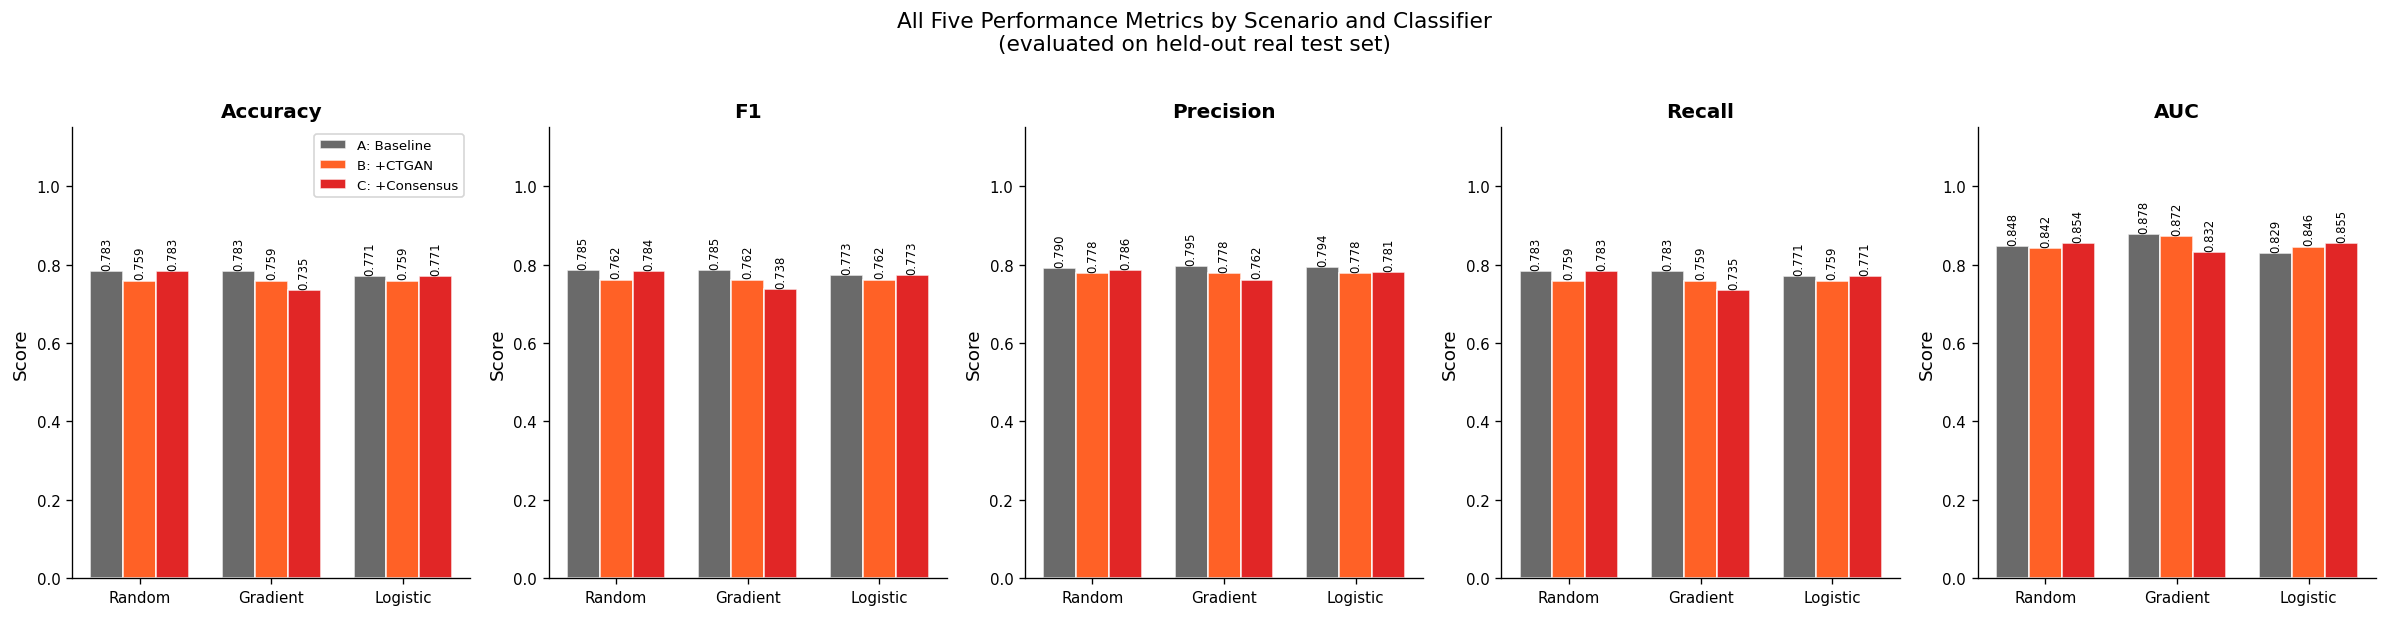

Figure saved.


In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        120,
    'savefig.dpi':       300,
})

METRICS    = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']
SCENARIOS  = performance_df['Scenario'].unique()
CLASSIFIERS= performance_df['Classifier'].unique()
COLORS     = ['#505050', '#FF4500', '#DC0000']  # one per scenario
SCENARIO_SHORT = ['A: Baseline', 'B: +CTGAN', 'C: +Consensus']

fig, axes = plt.subplots(1, len(METRICS), figsize=(20, 5))

x      = np.arange(len(CLASSIFIERS))
width  = 0.25

for ax, metric in zip(axes, METRICS):
    for i, (scenario, short, color) in enumerate(zip(SCENARIOS, SCENARIO_SHORT, COLORS)):
        vals = [
            performance_df[
                (performance_df['Scenario']   == scenario) &
                (performance_df['Classifier'] == clf)
            ][metric].values[0]
            for clf in CLASSIFIERS
        ]
        bars = ax.bar(x + i * width, vals, width, label=short,
                      color=color, alpha=0.85, edgecolor='white')

        # Annotate each bar with its exact value
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=90
            )

    ax.set_xticks(x + width)
    clf_short = [c.split()[0] for c in CLASSIFIERS]
    ax.set_xticklabels(clf_short, fontsize=9)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    if ax == axes[0]:
        ax.legend(fontsize=8, loc='upper right')

plt.suptitle('All Five Performance Metrics by Scenario and Classifier\n(evaluated on held-out real test set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('output/figures/all_metrics_detailed.png')
plt.show()
print('Figure saved.')

---

## Section 5f: ROC-Style AUC Bar Chart — Full Detail

AUC is plotted separately here with a baseline reference line at 0.5 (random classifier) and at 0.8 (conventionally considered good discrimination). Values above 0.8 indicate the model has strong ability to rank died patients above survived patients.

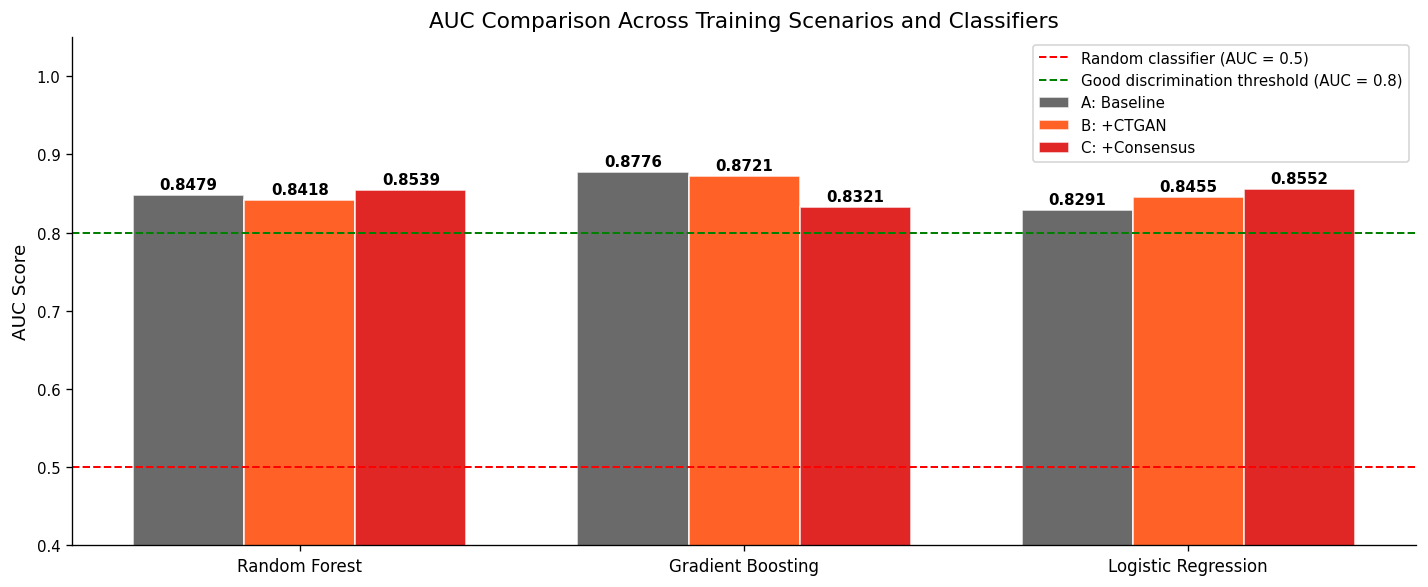

Figure saved.


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(len(CLASSIFIERS))
width = 0.25

for i, (scenario, short, color) in enumerate(zip(SCENARIOS, SCENARIO_SHORT, COLORS)):
    auc_vals = [
        float(performance_df[
            (performance_df['Scenario']   == scenario) &
            (performance_df['Classifier'] == clf)
        ]['AUC'].values[0])
        for clf in CLASSIFIERS
    ]
    bars = ax.bar(x + i * width, auc_vals, width, label=short,
                  color=color, alpha=0.85, edgecolor='white')

    for bar, val in zip(bars, auc_vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.004,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

ax.axhline(0.5, color='red',    linewidth=1.2, linestyle='--', label='Random classifier (AUC = 0.5)')
ax.axhline(0.8, color='green',  linewidth=1.2, linestyle='--', label='Good discrimination threshold (AUC = 0.8)')

ax.set_xticks(x + width)
ax.set_xticklabels(CLASSIFIERS, fontsize=10)
ax.set_ylabel('AUC Score')
ax.set_ylim(0.4, 1.05)
ax.set_title('AUC Comparison Across Training Scenarios and Classifiers', fontsize=13)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('output/figures/auc_detailed_comparison.png')
plt.show()
print('Figure saved.')

---

## Section 6: Publication Figures — Predictive Performance

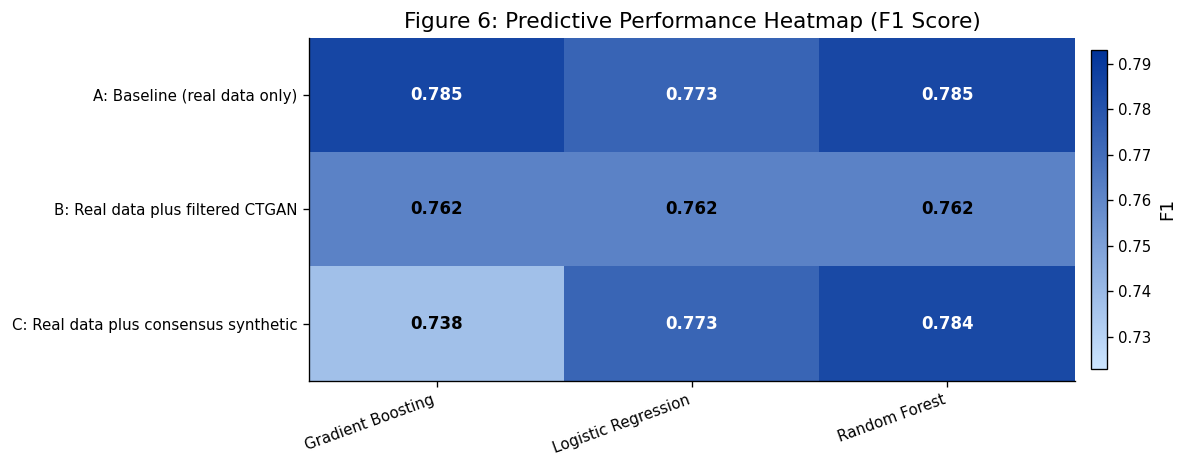

  Figure saved: /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/figures/fig6_performance_heatmap.png
Figure 6 (performance heatmap) saved.


In [13]:
plot_performance_heatmap(performance_df, metric='F1')
print('Figure 6 (performance heatmap) saved.')

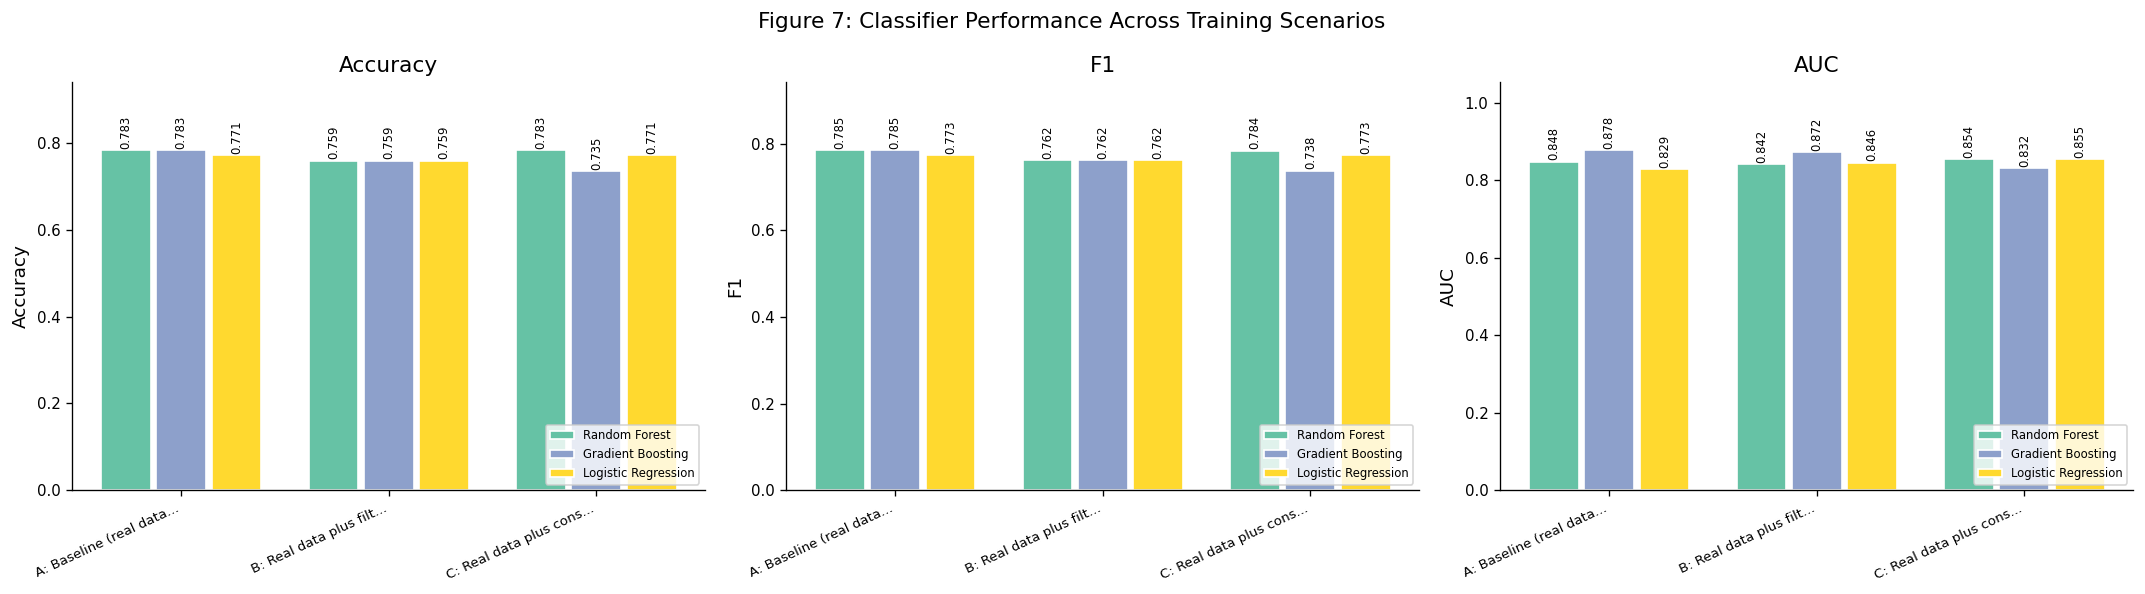

  Figure saved: /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/figures/fig7_model_comparison.png
Figure 7 (model comparison bar chart) saved.


In [14]:
plot_model_comparison(performance_df)
if ax == axes[0]:
        ax.legend(fontsize=8, loc='upper right')
print('Figure 7 (model comparison bar chart) saved.')

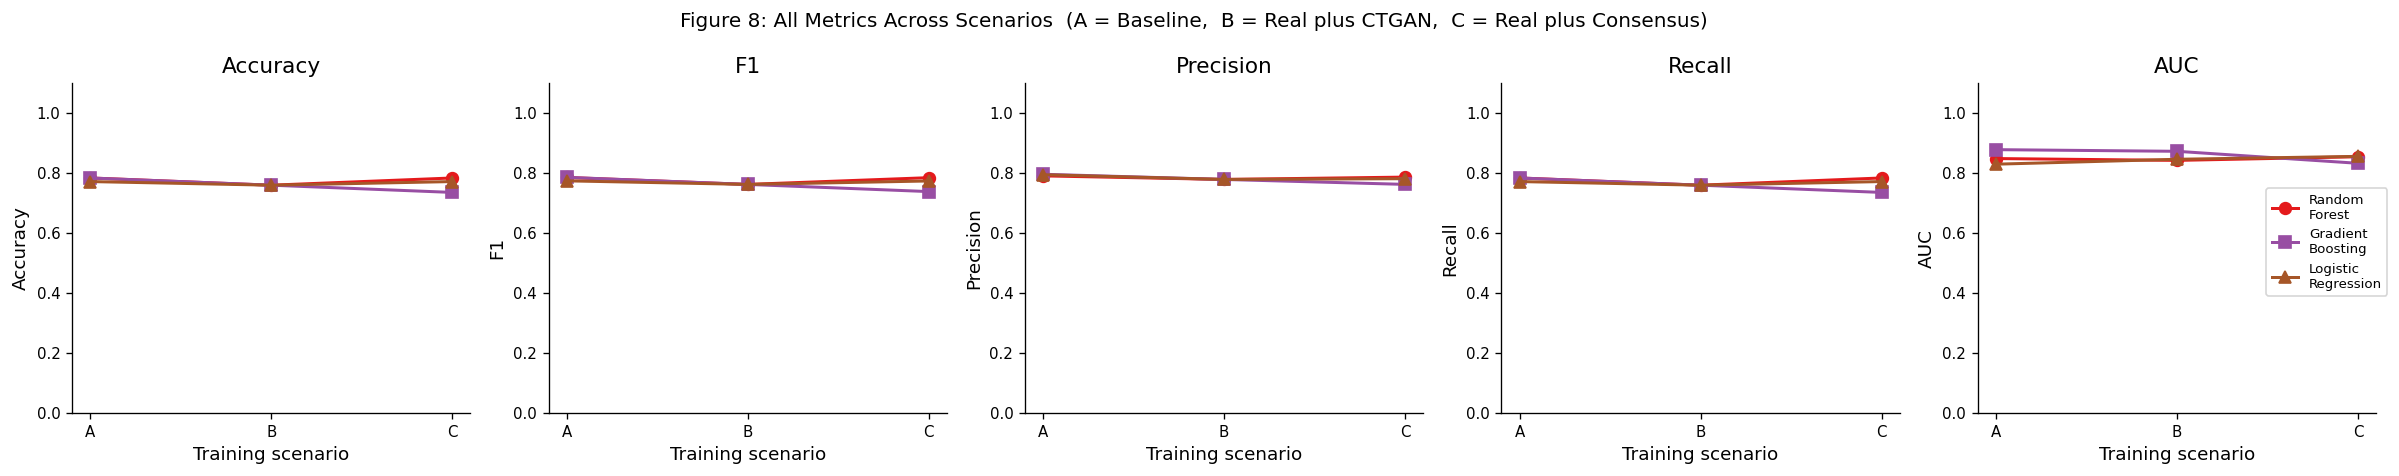

  Figure saved: /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/figures/fig8_all_metrics.png
Figure 8 (all metrics line plot) saved.


In [15]:
plot_all_metrics(performance_df)
print('Figure 8 (all metrics line plot) saved.')

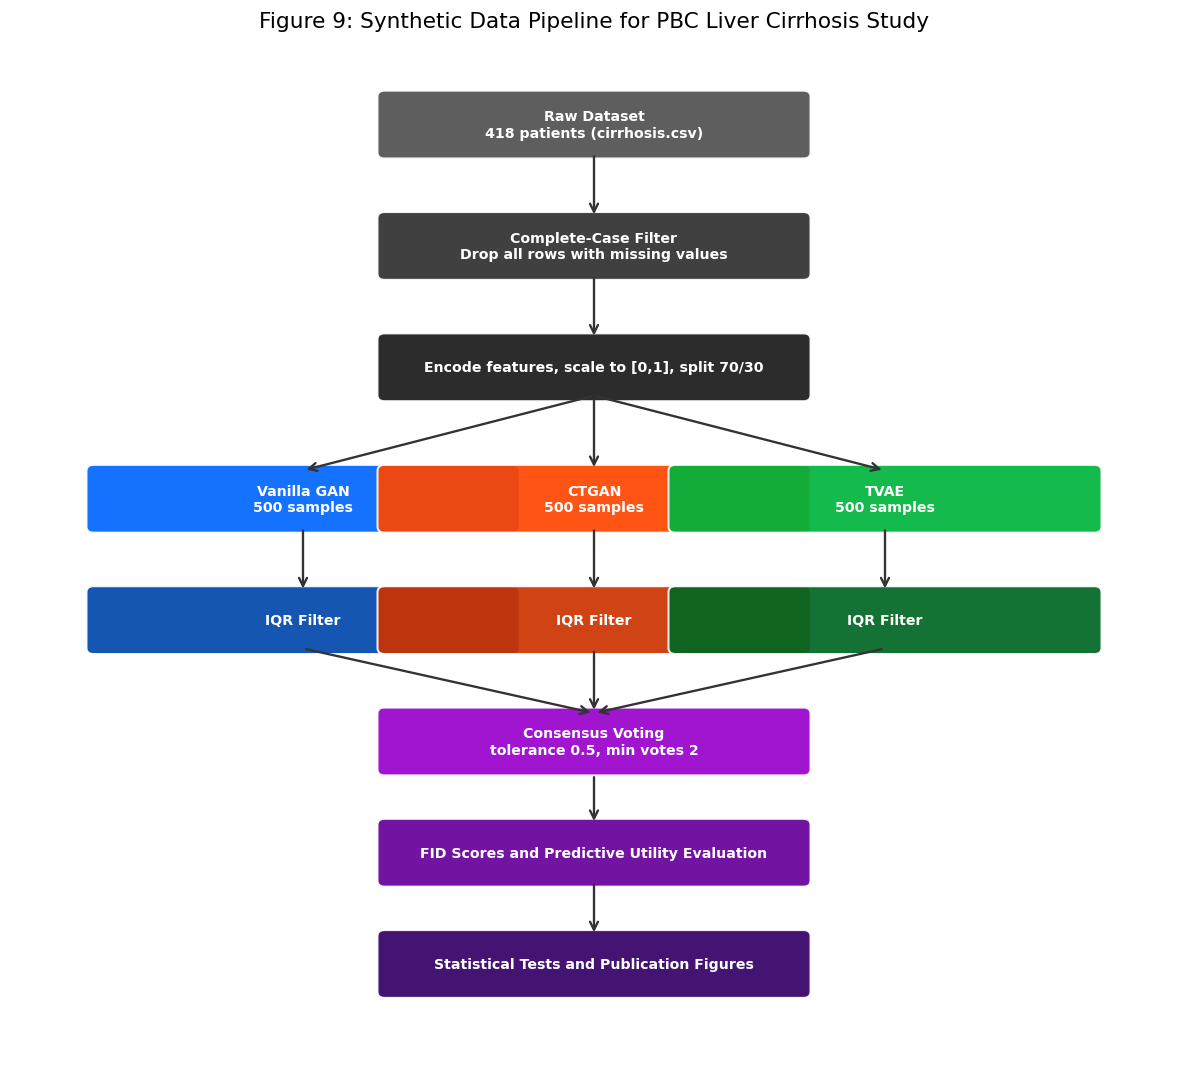

  Figure saved: /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/figures/fig9_pipeline_flowchart.png
Figure 9 (pipeline flowchart) saved.


In [16]:
plot_pipeline_flowchart()
print('Figure 9 (pipeline flowchart) saved.')

---

## Section 7: Statistical Test Summary

The statistical tests from Notebook 2 are summarised here alongside the predictive results to give a complete picture of how distributional fidelity relates to predictive utility.

In [17]:
if 'shapiro_wilk' in stats:
    normal_count = (stats['shapiro_wilk']['Normal'] == 'Yes').sum()
    total        = len(stats['shapiro_wilk'])
    print(f'Shapiro-Wilk: {normal_count} of {total} continuous features are normally distributed in the real data')
    print()
    print(stats['shapiro_wilk'].to_string(index=False))

Shapiro-Wilk: 3 of 11 continuous features are normally distributed in the real data

      Feature  W_statistic  p_value Normal
       N_Days       0.9718 0.000628     No
          Age       0.9907 0.251068    Yes
    Bilirubin       0.6361 0.000000     No
  Cholesterol       0.6762 0.000000     No
      Albumin       0.9899 0.194078    Yes
       Copper       0.7683 0.000000     No
     Alk_Phos       0.5909 0.000000     No
         SGOT       0.9482 0.000002     No
Tryglicerides       0.7989 0.000000     No
    Platelets       0.9873 0.082422    Yes
  Prothrombin       0.8773 0.000000     No


In [18]:
if 'ks_tests' in stats:
    ks = stats['ks_tests']
    sig = ks[ks['Significant_difference'] == 'Yes']
    print(f'KS tests: {len(sig)} of {len(ks)} feature-method combinations show a significant distributional difference (p < 0.05)')
    print()
    print('Significant differences by method:')
    print(sig.groupby('Method')['Feature'].count().rename('Features with significant difference').to_string())

KS tests: 37 of 44 feature-method combinations show a significant distributional difference (p < 0.05)

Significant differences by method:
Method
CTGAN (filtered)     7
Consensus           11
GAN (filtered)       8
TVAE (filtered)     11


In [19]:
if 'cohens_d' in stats:
    cd = stats['cohens_d']
    print('Cohen d effect size distribution by method:')
    print(cd.groupby(['Method', 'Effect_size']).size().unstack(fill_value=0).to_string())

Cohen d effect size distribution by method:
Effect_size       large  medium  negligible  small
Method                                            
CTGAN (filtered)      0       3           4      4
Consensus             0       0           5      6
GAN (filtered)        1       3           4      3
TVAE (filtered)       0       0          10      1


---

## Section 8: Full Summary Report

A plain-text summary report is written to `output/results/summary_report.txt`. This file brings together all key numbers from every step of the pipeline in one document, which is a useful starting point when writing the paper results section.

In [20]:
# Load synthetic raw counts for the report
synthetic_files = {'GAN': 'synthetic_gan.csv', 'CTGAN': 'synthetic_ctgan.csv', 'TVAE': 'synthetic_tvae.csv'}
raw_counts = {}
for name, fname in synthetic_files.items():
    path = os.path.join('output', 'data', fname)
    if os.path.exists(path):
        raw_counts[name] = len(pd.read_csv(path))

train_class = train_df[TARGET_COL].value_counts().sort_index().to_dict()

lines = [
    '=' * 68,
    'FULL PROJECT SUMMARY REPORT',
    'Beyond Distributional Similarity: Evaluating Predictive Utility',
    'of Synthetic Liver Cirrhosis Data',
    'Mayo Clinic Primary Biliary Cirrhosis Dataset',
    '=' * 68,
    '',
    'DATA PREPARATION',
    '',
    f'  Raw dataset rows                : 418',
    f'  Rows with any missing value     : 142',
    f'  Complete case rows retained     : 276',
    f'  Features used                   : 18 (11 continuous, 5 binary, 2 ordinal)',
    f'  Target variable                 : Status (0 = alive or transplant, 1 = died)',
    f'  Training set size               : {len(train_df)} patients',
    f'  Test set size (held out)        : {len(test_df)} patients',
    f'  Training class balance          : {train_class.get(0, 0)} survived, {train_class.get(1, 0)} died',
    f'  Split method                    : Stratified 70/30, random seed 42',
    '',
    'SYNTHETIC DATA GENERATION',
    '',
]

for name in ['GAN', 'CTGAN', 'TVAE']:
    raw_n = raw_counts.get(name, 'N/A')
    filtered_n = len(pd.read_csv(f'output/data/filtered_{name.lower()}.csv')) if os.path.exists(f'output/data/filtered_{name.lower()}.csv') else 'N/A'
    if isinstance(raw_n, int) and isinstance(filtered_n, int):
        pct = filtered_n / raw_n * 100
        lines.append(f'  {name:<8}  generated {raw_n}  after IQR filter {filtered_n} kept ({pct:.1f}% retained)')
    else:
        lines.append(f'  {name:<8}  data not found')

lines += [
    '',
    'CONSENSUS VOTING',
    '',
    f'  Total consensus records         : {len(consensus_df)}',
]
for _, row in consensus_summary.iterrows():
    lines.append(f'  Records from {row["Source"]:<8}: {int(row["Count"])}  ({row["Percentage"]}%)')

lines += [
    '',
    'FID SCORES (lower is better)',
    '',
]
for _, row in fid_df.iterrows():
    lines.append(f'  {row["Method"]:<25}  FID = {row["FID"]:.4f}  (n = {row["n_samples"]})')

lines += [
    '',
    'PREDICTIVE UTILITY (evaluated on held-out real test set)',
    '',
]
for _, row in performance_df.iterrows():
    lines.append(
        f'  {row["Scenario"][:38]:<38}  {row["Classifier"]:<22}  '
        f'Accuracy {row["Accuracy"]:.4f}  F1 {row["F1"]:.4f}  AUC {row["AUC"]}'
    )

lines += [
    '',
    'STATISTICAL TESTS',
    '',
]
for test_name, df in stats.items():
    lines.append(f'  {test_name:<20} : {len(df)} tests run')

lines += [
    '',
    'OUTPUT FILES',
    '',
    '  output/data/      all CSV data files (real, synthetic, filtered, consensus)',
    '  output/figures/   10 publication figures at 300 DPI',
    '  output/results/   numeric result tables and this report',
    '',
    '=' * 68,
]

report_text = '\n'.join(lines)
print(report_text)

report_path = 'output/results/summary_report.txt'
with open(report_path, 'w') as f:
    f.write(report_text)

print(f'\nReport saved to {report_path}')

FULL PROJECT SUMMARY REPORT
Beyond Distributional Similarity: Evaluating Predictive Utility
of Synthetic Liver Cirrhosis Data
Mayo Clinic Primary Biliary Cirrhosis Dataset

DATA PREPARATION

  Raw dataset rows                : 418
  Rows with any missing value     : 142
  Complete case rows retained     : 276
  Features used                   : 18 (11 continuous, 5 binary, 2 ordinal)
  Target variable                 : Status (0 = alive or transplant, 1 = died)
  Training set size               : 193 patients
  Test set size (held out)        : 83 patients
  Training class balance          : 115 survived, 78 died
  Split method                    : Stratified 70/30, random seed 42

SYNTHETIC DATA GENERATION

  GAN       generated 500  after IQR filter 226 kept (45.2% retained)
  CTGAN     generated 500  after IQR filter 210 kept (42.0% retained)
  TVAE      generated 500  after IQR filter 500 kept (100.0% retained)

CONSENSUS VOTING

  Total consensus records         : 782
  Records fr

---

## Section 10: SMOTE Baseline — Synthetic Augmentation Without Generative Models

SMOTE (Synthetic Minority Oversampling Technique) is a classical approach to class imbalance. It generates new minority-class samples by interpolating between existing observations in feature space. Including a SMOTE baseline answers whether our generative model approach offers any advantage over a simpler interpolation-based method.

Scenario D trains the same three classifiers on real data augmented with SMOTE to match the approximate size of Scenario B. This provides a direct comparison between deep generative augmentation and SMOTE augmentation.

In [21]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing  import StandardScaler
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.metrics        import (accuracy_score, f1_score, precision_score,
                                    recall_score, roc_auc_score)

feat_cols  = [c for c in ALL_FEATURE_COLS if c in train_df.columns]
X_tr_raw   = train_df[feat_cols].values
y_tr_raw   = np.round(train_df[TARGET_COL].values).astype(int)
X_te_raw   = test_df[feat_cols].values
y_test_arr = np.round(test_df[TARGET_COL].values).astype(int)

# Scale first so SMOTE operates in standardised feature space
scaler_smote  = StandardScaler()
X_tr_s        = scaler_smote.fit_transform(X_tr_raw)
X_te_s        = scaler_smote.transform(X_te_raw)

sm = SMOTE(random_state=42, k_neighbors=5)
X_tr_sm, y_tr_sm = sm.fit_resample(X_tr_s, y_tr_raw)

print(f'Before SMOTE  :  {len(X_tr_raw)} training samples')
print(f'After SMOTE   :  {len(X_tr_sm)} training samples')
print(f'  Class 0 (survived / transplant) : {(y_tr_sm == 0).sum()}')
print(f'  Class 1 (died)                  : {(y_tr_sm == 1).sum()}')
print()

clf_map_smote = {
    'Random Forest'     : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'),
}

smote_records = []
for clf_name, clf in clf_map_smote.items():
    clf.fit(X_tr_sm, y_tr_sm)
    y_pred = clf.predict(X_te_s)
    y_prob = clf.predict_proba(X_te_s)[:, 1]
    row = {
        'Scenario'  : 'D: Real data plus SMOTE',
        'Classifier': clf_name,
        'n_train'   : len(X_tr_sm),
        'Accuracy'  : round(accuracy_score(y_test_arr, y_pred), 4),
        'F1'        : round(f1_score(y_test_arr, y_pred, average='weighted', zero_division=0), 4),
        'Precision' : round(precision_score(y_test_arr, y_pred, average='weighted', zero_division=0), 4),
        'Recall'    : round(recall_score(y_test_arr, y_pred, average='weighted', zero_division=0), 4),
        'AUC'       : round(roc_auc_score(y_test_arr, y_prob), 4),
    }
    smote_records.append(row)
    print(f'  {clf_name:<22}  Accuracy {row["Accuracy"]:.4f}  '
          f'F1 {row["F1"]:.4f}  AUC {row["AUC"]:.4f}')

smote_df        = pd.DataFrame(smote_records)
all_scenario_df = pd.concat([performance_df, smote_df], ignore_index=True)
smote_df.to_csv('output/results/smote_results.csv', index=False)

print()
print('F1 comparison across all four scenarios:')
print()
pivot_all = all_scenario_df.pivot(index='Scenario', columns='Classifier', values='F1').round(4)
display(pivot_all)

Before SMOTE  :  193 training samples
After SMOTE   :  230 training samples
  Class 0 (survived / transplant) : 115
  Class 1 (died)                  : 115



/Users/michaeludousoro/Desktop/liver_cirrhosis_article/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


  Random Forest           Accuracy 0.7470  F1 0.7496  AUC 0.8388
  Gradient Boosting       Accuracy 0.8072  F1 0.8087  AUC 0.8661
  Logistic Regression     Accuracy 0.7711  F1 0.7735  AUC 0.8297

F1 comparison across all four scenarios:



Classifier,Gradient Boosting,Logistic Regression,Random Forest
Scenario,,,
A: Baseline (real data only),0.7852,0.7735,0.7848
B: Real data plus filtered CTGAN,0.7616,0.7616,0.7616
C: Real data plus consensus synthetic,0.7377,0.7731,0.7841
D: Real data plus SMOTE,0.8087,0.7735,0.7496


---

## Section 11: 5-Fold Stratified Cross-Validation

Cross-validation provides a more robust estimate of generalisation performance by training and evaluating on five non-overlapping splits of the data. Stratification ensures each fold preserves the same class ratio as the full dataset. We report the mean and standard deviation of the AUC across folds for every scenario and classifier combination.

For the SMOTE scenario, oversampling is applied inside each fold to avoid data leakage (synthetic samples are never computed from validation observations).

In [22]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base            import clone

feat_cols_cv = [c for c in ALL_FEATURE_COLS if c in train_df.columns]

def combine_clean_cv(*dfs):
    combined = pd.concat(list(dfs), ignore_index=True)
    return combined.dropna(subset=feat_cols_cv + [TARGET_COL])

cv_scenarios = {
    'A: Baseline (real data only)'         : train_df,
    'B: Real data plus filtered CTGAN'     : combine_clean_cv(train_df, filtered_ctgan),
    'C: Real data plus consensus synthetic': combine_clean_cv(train_df, consensus_df),
    'D: Real data plus SMOTE'              : 'smote',
}

base_clfs = {
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'),
}

cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_records  = []

for scenario_name, scenario_data in cv_scenarios.items():
    use_smote = isinstance(scenario_data, str) and scenario_data == 'smote'
    X_cv = train_df[feat_cols_cv].values
    y_cv = np.round(train_df[TARGET_COL].values).astype(int)
    if not use_smote:
        X_cv = scenario_data[feat_cols_cv].values
        y_cv = np.round(scenario_data[TARGET_COL].values).astype(int)

    for clf_name, base_clf in base_clfs.items():
        fold_aucs = []
        for tr_idx, va_idx in cv_splitter.split(X_cv, y_cv):
            X_tr_f, X_va_f = X_cv[tr_idx], X_cv[va_idx]
            y_tr_f, y_va_f = y_cv[tr_idx], y_cv[va_idx]

            sc_f = StandardScaler()
            X_tr_fs = sc_f.fit_transform(X_tr_f)
            X_va_fs = sc_f.transform(X_va_f)

            if use_smote:
                k = min(5, int((y_tr_f == 1).sum()) - 1)
                sm_f = SMOTE(random_state=42, k_neighbors=max(1, k))
                X_tr_fs, y_tr_f = sm_f.fit_resample(X_tr_fs, y_tr_f)

            clf_f = clone(base_clf)
            clf_f.fit(X_tr_fs, y_tr_f)
            fold_aucs.append(roc_auc_score(y_va_f, clf_f.predict_proba(X_va_fs)[:, 1]))

        mean_auc = np.mean(fold_aucs)
        std_auc  = np.std(fold_aucs)
        cv_records.append({
            'Scenario'  : scenario_name,
            'Classifier': clf_name,
            'Mean AUC'  : round(mean_auc, 4),
            'Std AUC'   : round(std_auc, 4),
            'CI Lower'  : round(mean_auc - 1.96 * std_auc, 4),
            'CI Upper'  : round(mean_auc + 1.96 * std_auc, 4),
        })

cv_df = pd.DataFrame(cv_records)
cv_df.to_csv('output/results/cv_results.csv', index=False)

print('5-fold CV mean AUC:')
print()
print(cv_df.pivot(index='Scenario', columns='Classifier', values='Mean AUC').round(4).to_string())
print()
print('5-fold CV AUC std:')
print()
print(cv_df.pivot(index='Scenario', columns='Classifier', values='Std AUC').round(4).to_string())
print()
print('Results saved to output/results/cv_results.csv')

/Users/michaeludousoro/Desktop/liver_cirrhosis_article/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/michaeludousoro/Desktop/liver_cirrhosis_article/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/michaeludousoro/Desktop/liver_cirrhosis_article/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part

5-fold CV mean AUC:

Classifier                             Gradient Boosting  Logistic Regression  Random Forest
Scenario                                                                                    
A: Baseline (real data only)                      0.8539               0.8522         0.8843
B: Real data plus filtered CTGAN                  0.8730               0.8670         0.8910
C: Real data plus consensus synthetic             0.8920               0.8727         0.9171
D: Real data plus SMOTE                           0.8604               0.8521         0.8859

5-fold CV AUC std:

Classifier                             Gradient Boosting  Logistic Regression  Random Forest
Scenario                                                                                    
A: Baseline (real data only)                      0.0710               0.0491         0.0537
B: Real data plus filtered CTGAN                  0.0317               0.0339         0.0276
C: Real data plus consensus 

/Users/michaeludousoro/Desktop/liver_cirrhosis_article/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/michaeludousoro/Desktop/liver_cirrhosis_article/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/michaeludousoro/Desktop/liver_cirrhosis_article/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part

---

## Section 12: Bootstrap Confidence Intervals for Test-Set AUC

With 83 test patients, point estimates of AUC can be unstable. Bootstrap resampling draws 1 000 samples with replacement from the test set predictions and computes AUC each time. The 2.5th and 97.5th percentiles form a 95 percent confidence interval. This section also trains and stores all models needed for the ROC curves, Precision-Recall curves, and feature importance analyses that follow.

In [23]:
feat_cols_b = [c for c in ALL_FEATURE_COLS if c in train_df.columns]
X_te_b      = test_df[feat_cols_b].values
y_test_b    = np.round(test_df[TARGET_COL].values).astype(int)

def combine_clean_b(*dfs):
    combined = pd.concat(list(dfs), ignore_index=True)
    return combined.dropna(subset=feat_cols_b + [TARGET_COL])

base_scenarios = {
    'A: Baseline (real data only)'         : train_df,
    'B: Real data plus filtered CTGAN'     : combine_clean_b(train_df, filtered_ctgan),
    'C: Real data plus consensus synthetic': combine_clean_b(train_df, consensus_df),
}

# These dicts are used by Sections 14, 15, and 16 as well
trained_probs     = {}
trained_clf_objs  = {}
feat_cols_shared  = feat_cols_b  # shared reference for later sections

for scenario_name, train_data in base_scenarios.items():
    X_tr_b = train_data[feat_cols_b].values
    y_tr_b = np.round(train_data[TARGET_COL].values).astype(int)

    sc_b      = StandardScaler()
    X_tr_bs   = sc_b.fit_transform(X_tr_b)
    X_te_bs   = sc_b.transform(X_te_b)

    trained_probs[scenario_name]    = {}
    trained_clf_objs[scenario_name] = {}

    for clf_name, clf in {
        'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'),
    }.items():
        clf.fit(X_tr_bs, y_tr_b)
        trained_probs[scenario_name][clf_name]   = clf.predict_proba(X_te_bs)[:, 1]
        trained_clf_objs[scenario_name][clf_name] = clf

print('Models trained. Running 1 000 bootstrap resamples...')
print()

N_BOOT = 1000
rng    = np.random.RandomState(42)
n_te   = len(y_test_b)

boot_records = []
for scenario_name in base_scenarios:
    for clf_name in ['Random Forest', 'Gradient Boosting', 'Logistic Regression']:
        y_prob = trained_probs[scenario_name][clf_name]
        boot_aucs = []
        for _ in range(N_BOOT):
            idx = rng.randint(0, n_te, size=n_te)
            y_b  = y_test_b[idx]
            yp_b = y_prob[idx]
            if len(np.unique(y_b)) < 2:
                continue
            boot_aucs.append(roc_auc_score(y_b, yp_b))

        pt  = roc_auc_score(y_test_b, y_prob)
        cil = np.percentile(boot_aucs, 2.5)
        ciu = np.percentile(boot_aucs, 97.5)

        boot_records.append({
            'Scenario'  : scenario_name,
            'Classifier': clf_name,
            'AUC'       : round(pt, 4),
            'CI Lower'  : round(cil, 4),
            'CI Upper'  : round(ciu, 4),
        })
        print(f'{scenario_name[:30]:<30}  {clf_name:<22}  '
              f'AUC = {pt:.4f}  95% CI [{cil:.4f}, {ciu:.4f}]')

boot_df = pd.DataFrame(boot_records)
boot_df.to_csv('output/results/bootstrap_ci.csv', index=False)
print()
print('Bootstrap CI results saved to output/results/bootstrap_ci.csv')

Models trained. Running 1 000 bootstrap resamples...

A: Baseline (real data only)    Random Forest           AUC = 0.8479  95% CI [0.7540, 0.9383]
A: Baseline (real data only)    Gradient Boosting       AUC = 0.8776  95% CI [0.7883, 0.9480]
A: Baseline (real data only)    Logistic Regression     AUC = 0.8291  95% CI [0.7275, 0.9156]
B: Real data plus filtered CTG  Random Forest           AUC = 0.8418  95% CI [0.7424, 0.9335]
B: Real data plus filtered CTG  Gradient Boosting       AUC = 0.8721  95% CI [0.7755, 0.9484]
B: Real data plus filtered CTG  Logistic Regression     AUC = 0.8455  95% CI [0.7455, 0.9336]
C: Real data plus consensus sy  Random Forest           AUC = 0.8539  95% CI [0.7596, 0.9332]
C: Real data plus consensus sy  Gradient Boosting       AUC = 0.8321  95% CI [0.7314, 0.9193]
C: Real data plus consensus sy  Logistic Regression     AUC = 0.8552  95% CI [0.7555, 0.9348]

Bootstrap CI results saved to output/results/bootstrap_ci.csv


---

## Section 13: McNemar's Test — Statistical Comparison Between Scenarios

McNemar's test evaluates whether two classifiers make significantly different errors on the same test set. It is the appropriate paired test here because all classifiers are evaluated on the exact same 83 patients. We compare Scenarios B and C against the Scenario A baseline for each classifier. A p-value below 0.05 indicates the two scenarios produced statistically different classification patterns.

In [24]:
from scipy.stats import binomtest

feat_cols_mc = [c for c in ALL_FEATURE_COLS if c in train_df.columns]
X_te_mc      = test_df[feat_cols_mc].values
y_test_mc    = np.round(test_df[TARGET_COL].values).astype(int)

def get_preds_mc(train_data):
    X_tr = train_data[feat_cols_mc].values
    y_tr = np.round(train_data[TARGET_COL].values).astype(int)
    sc   = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te_mc)
    out = {}
    for nm, clf in {
        'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'),
    }.items():
        clf.fit(X_tr_s, y_tr)
        out[nm] = clf.predict(X_te_s)
    return out

def combine_clean_mc(*dfs):
    combined = pd.concat(list(dfs), ignore_index=True)
    return combined.dropna(subset=feat_cols_mc + [TARGET_COL])

preds_A = get_preds_mc(train_df)
preds_B = get_preds_mc(combine_clean_mc(train_df, filtered_ctgan))
preds_C = get_preds_mc(combine_clean_mc(train_df, consensus_df))

mcnemar_records = []
print('McNemar exact test — comparing Scenario B and C against Scenario A baseline:')
print()

for clf_name in ['Random Forest', 'Gradient Boosting', 'Logistic Regression']:
    print(f'  Classifier: {clf_name}')
    correct_A = (preds_A[clf_name] == y_test_mc)

    for label, preds_X in [('B: Real + CTGAN', preds_B), ('C: Real + Consensus', preds_C)]:
        correct_X = (preds_X[clf_name] == y_test_mc)
        n10 = int((correct_A & ~correct_X).sum())   # A correct, X wrong
        n01 = int((~correct_A & correct_X).sum())   # A wrong,  X correct
        n   = n10 + n01

        if n == 0:
            p_val = 1.0
        else:
            result = binomtest(min(n10, n01), n=n, p=0.5, alternative='two-sided')
            p_val  = result.pvalue

        sig = 'Significant (p < 0.05)' if p_val < 0.05 else 'Not significant'
        print(f'    vs {label:<22}  n10 = {n10}  n01 = {n01}  '
              f'p = {p_val:.4f}  {sig}')

        mcnemar_records.append({
            'Classifier'       : clf_name,
            'Scenario_baseline': 'A: Baseline',
            'Scenario_compare' : label,
            'n10'              : n10,
            'n01'              : n01,
            'p_value'          : round(p_val, 4),
            'Significant'      : 'Yes' if p_val < 0.05 else 'No',
        })
    print()

pd.DataFrame(mcnemar_records).to_csv('output/results/mcnemar_tests.csv', index=False)
print('McNemar results saved to output/results/mcnemar_tests.csv')

McNemar exact test — comparing Scenario B and C against Scenario A baseline:

  Classifier: Random Forest
    vs B: Real + CTGAN         n10 = 3  n01 = 1  p = 0.6250  Not significant
    vs C: Real + Consensus     n10 = 2  n01 = 2  p = 1.0000  Not significant

  Classifier: Gradient Boosting
    vs B: Real + CTGAN         n10 = 4  n01 = 2  p = 0.6875  Not significant
    vs C: Real + Consensus     n10 = 6  n01 = 2  p = 0.2891  Not significant

  Classifier: Logistic Regression
    vs B: Real + CTGAN         n10 = 2  n01 = 1  p = 1.0000  Not significant
    vs C: Real + Consensus     n10 = 4  n01 = 4  p = 1.0000  Not significant

McNemar results saved to output/results/mcnemar_tests.csv


---

## Section 14: ROC Curves

The Receiver Operating Characteristic (ROC) curve plots the true positive rate against the false positive rate at every possible decision threshold. The area under the curve (AUC) summarises discrimination across all thresholds. A curve closer to the top-left corner indicates stronger performance. The diagonal dashed line represents a random classifier.

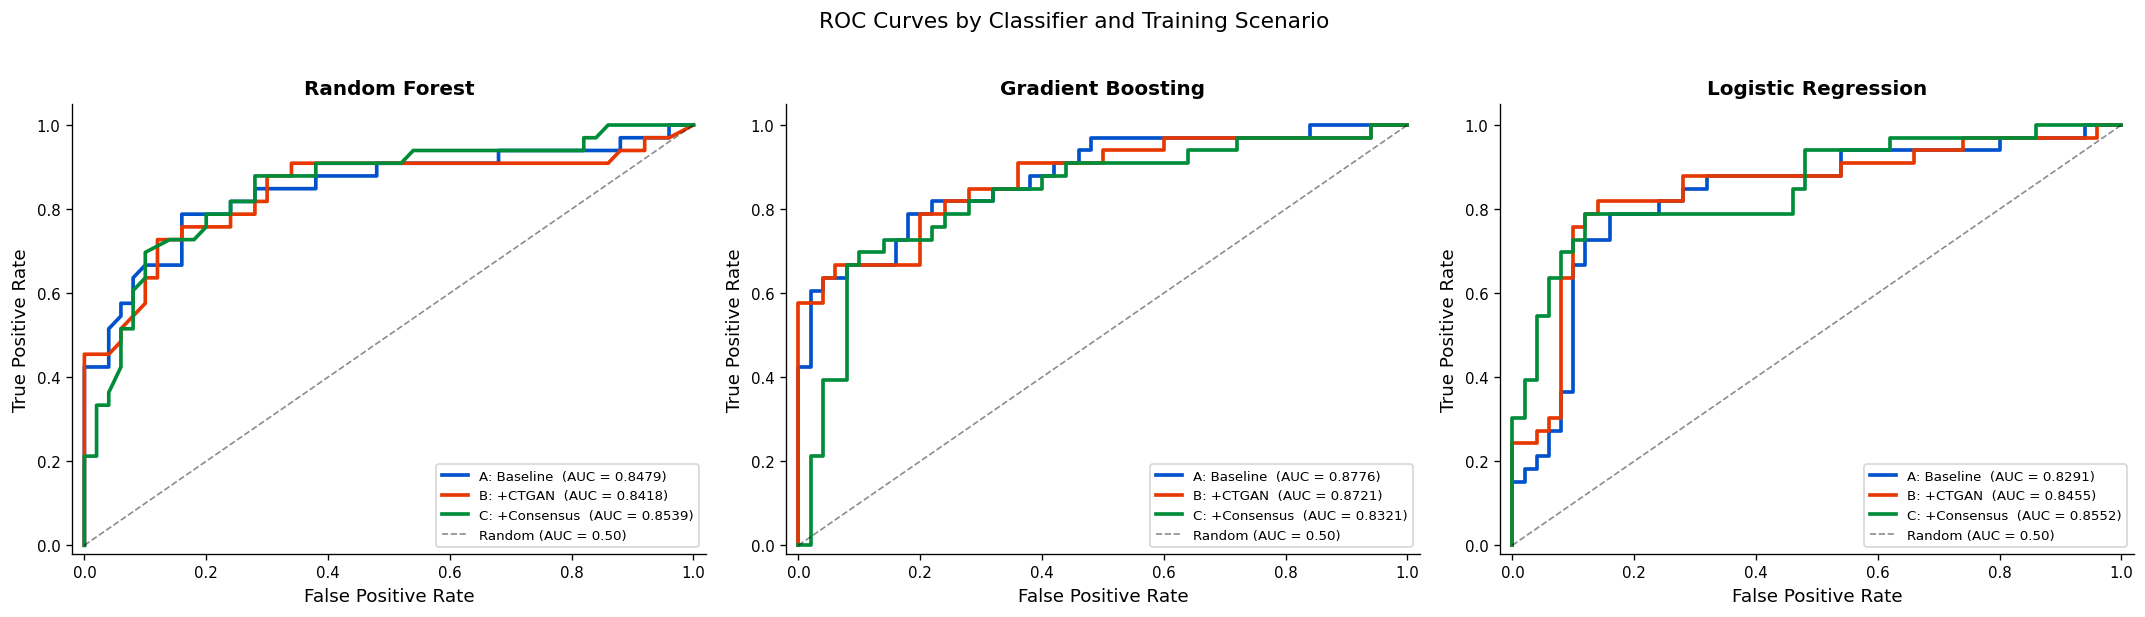

ROC curves saved to output/figures/roc_curves.png


In [25]:
from sklearn.metrics import roc_curve

SCEN_COLORS = ['#0052CC', '#E63800', '#008C38']
SCEN_SHORT  = ['A: Baseline', 'B: +CTGAN', 'C: +Consensus']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, clf_name in enumerate(['Random Forest', 'Gradient Boosting', 'Logistic Regression']):
    ax = axes[ax_idx]
    for sc_name, color, short in zip(list(base_scenarios.keys()), SCEN_COLORS, SCEN_SHORT):
        y_prob = trained_probs[sc_name][clf_name]
        fpr, tpr, _ = roc_curve(y_test_b, y_prob)
        auc_val = roc_auc_score(y_test_b, y_prob)
        ax.plot(fpr, tpr, color=color, linewidth=2.2,
                label=f'{short}  (AUC = {auc_val:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.45,
            label='Random (AUC = 0.50)')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate',  fontsize=11)
    ax.set_title(clf_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('ROC Curves by Classifier and Training Scenario',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('output/figures/roc_curves.png')
plt.show()
print('ROC curves saved to output/figures/roc_curves.png')

---

## Section 15: Precision-Recall Curves

The Precision-Recall curve plots precision against recall at every decision threshold. Unlike the ROC curve, it does not incorporate true negatives, which makes it more informative when the dataset is imbalanced. The horizontal dashed line shows the no-skill baseline, which equals the proportion of positive cases in the test set. Average Precision (AP) summarises the area under this curve.

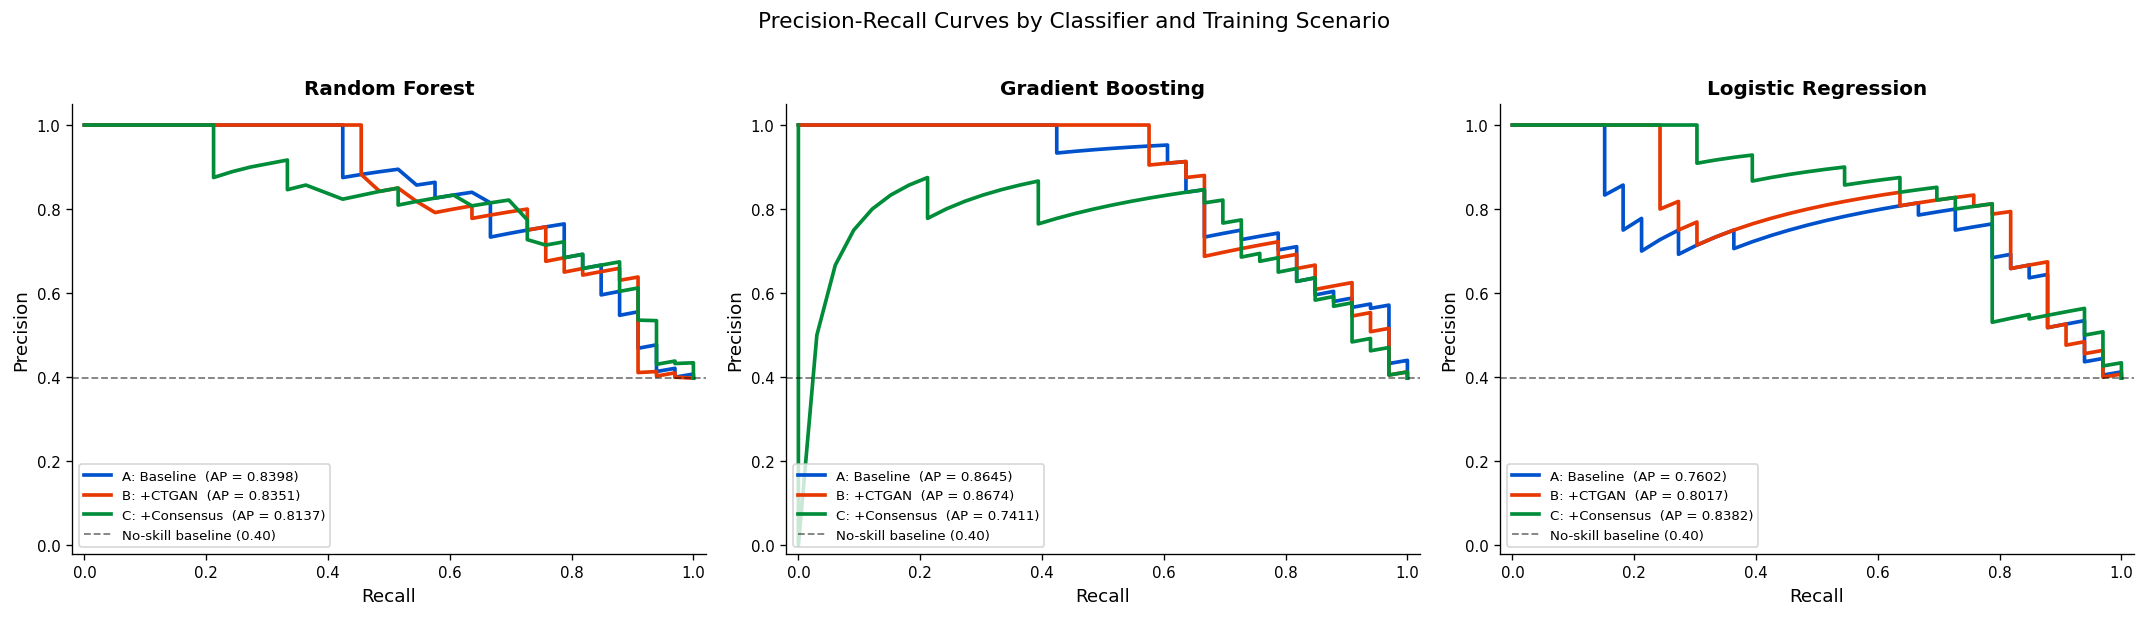

Precision-Recall curves saved to output/figures/pr_curves.png


In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score

baseline_rate = y_test_b.mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, clf_name in enumerate(['Random Forest', 'Gradient Boosting', 'Logistic Regression']):
    ax = axes[ax_idx]
    for sc_name, color, short in zip(list(base_scenarios.keys()), SCEN_COLORS, SCEN_SHORT):
        y_prob = trained_probs[sc_name][clf_name]
        prec, rec, _ = precision_recall_curve(y_test_b, y_prob)
        ap = average_precision_score(y_test_b, y_prob)
        ax.plot(rec, prec, color=color, linewidth=2.2,
                label=f'{short}  (AP = {ap:.4f})')

    ax.axhline(baseline_rate, color='black', linewidth=1.1, linestyle='--',
               alpha=0.5, label=f'No-skill baseline ({baseline_rate:.2f})')
    ax.set_xlabel('Recall',    fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(clf_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower left')
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Precision-Recall Curves by Classifier and Training Scenario',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('output/figures/pr_curves.png')
plt.show()
print('Precision-Recall curves saved to output/figures/pr_curves.png')

---

## Section 16: Feature Importance — Which Clinical Variables Drive Predictions

Random Forest and Gradient Boosting both produce built-in feature importance scores. For Random Forest the score is the mean decrease in Gini impurity across all trees. For Gradient Boosting it is the total reduction in the loss function attributed to each feature across all boosting rounds. Features that rank highly in both models are the strongest predictors of patient survival status.

We show importances for Scenario A (trained on real data only) because this reflects what the models learn from the authentic clinical data, unaffected by any augmentation.

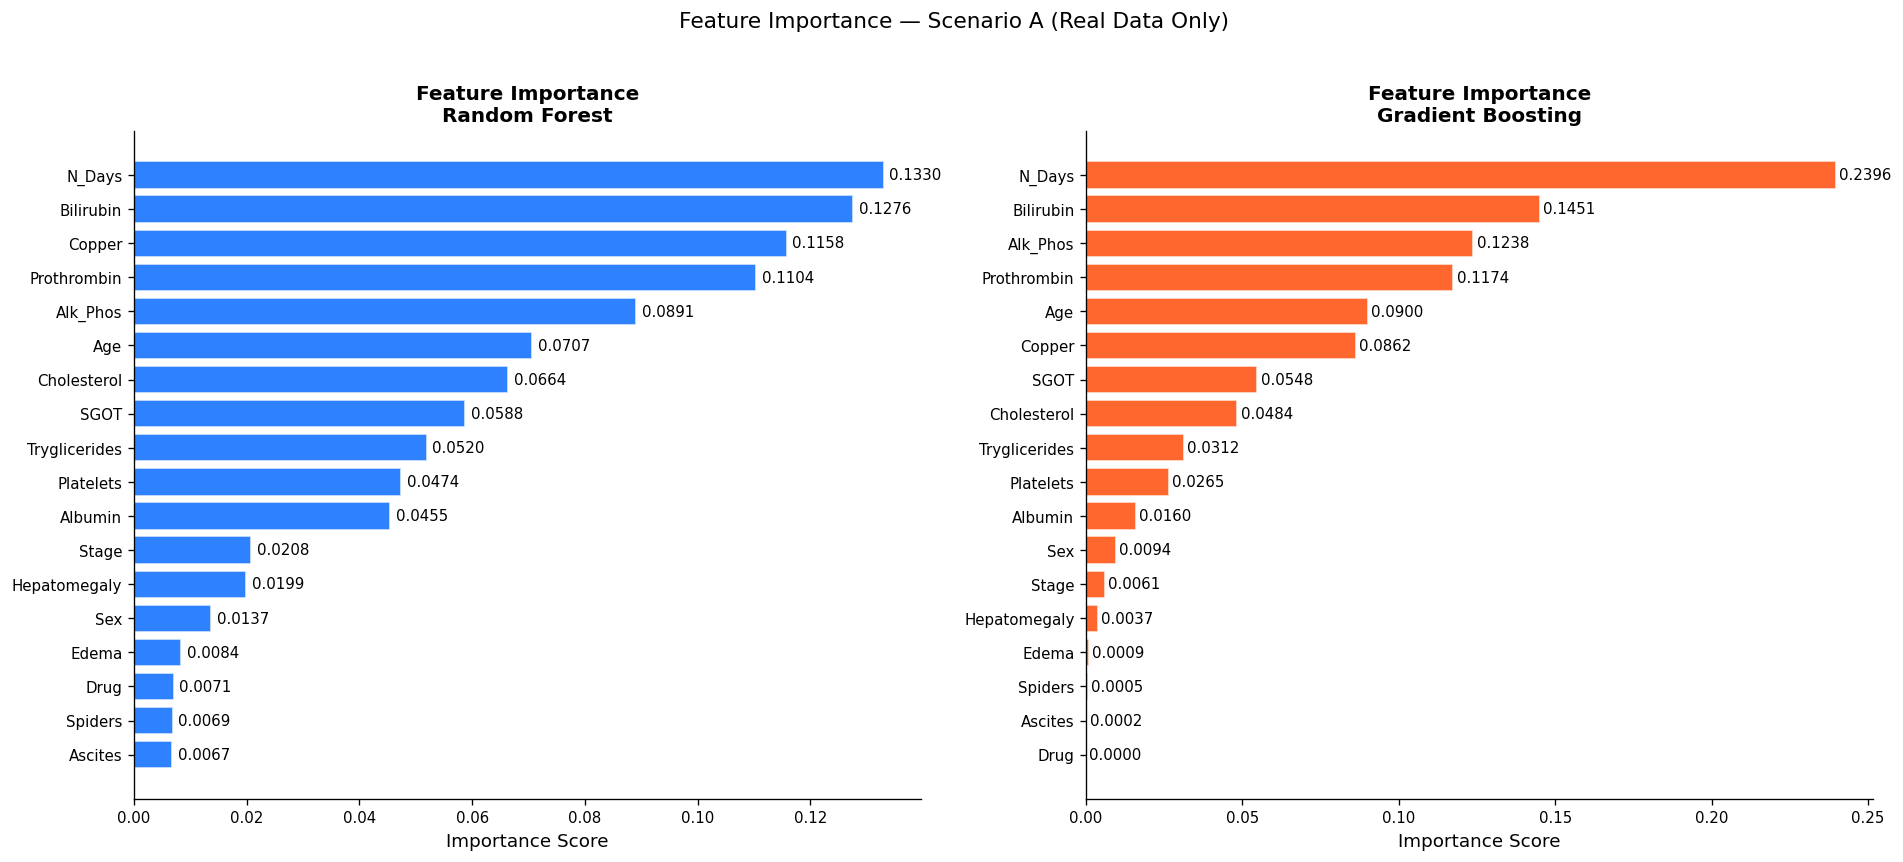

Feature importance figure saved to output/figures/feature_importance.png


In [27]:
rf_model = trained_clf_objs['A: Baseline (real data only)']['Random Forest']
gb_model = trained_clf_objs['A: Baseline (real data only)']['Gradient Boosting']

rf_imp = pd.Series(rf_model.feature_importances_, index=feat_cols_shared).sort_values(ascending=False)
gb_imp = pd.Series(gb_model.feature_importances_, index=feat_cols_shared).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, imp, model_name, bar_color in [
    (axes[0], rf_imp, 'Random Forest',     '#0066FF'),
    (axes[1], gb_imp, 'Gradient Boosting', '#FF4500'),
]:
    bars = ax.barh(imp.index[::-1], imp.values[::-1],
                   color=bar_color, alpha=0.82, edgecolor='white')
    for bar, val in zip(bars, imp.values[::-1]):
        ax.text(bar.get_width() + 0.001,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha='left', fontsize=9)
    ax.set_title(f'Feature Importance\n{model_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature Importance — Scenario A (Real Data Only)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('output/figures/feature_importance.png')
plt.show()
print('Feature importance figure saved to output/figures/feature_importance.png')

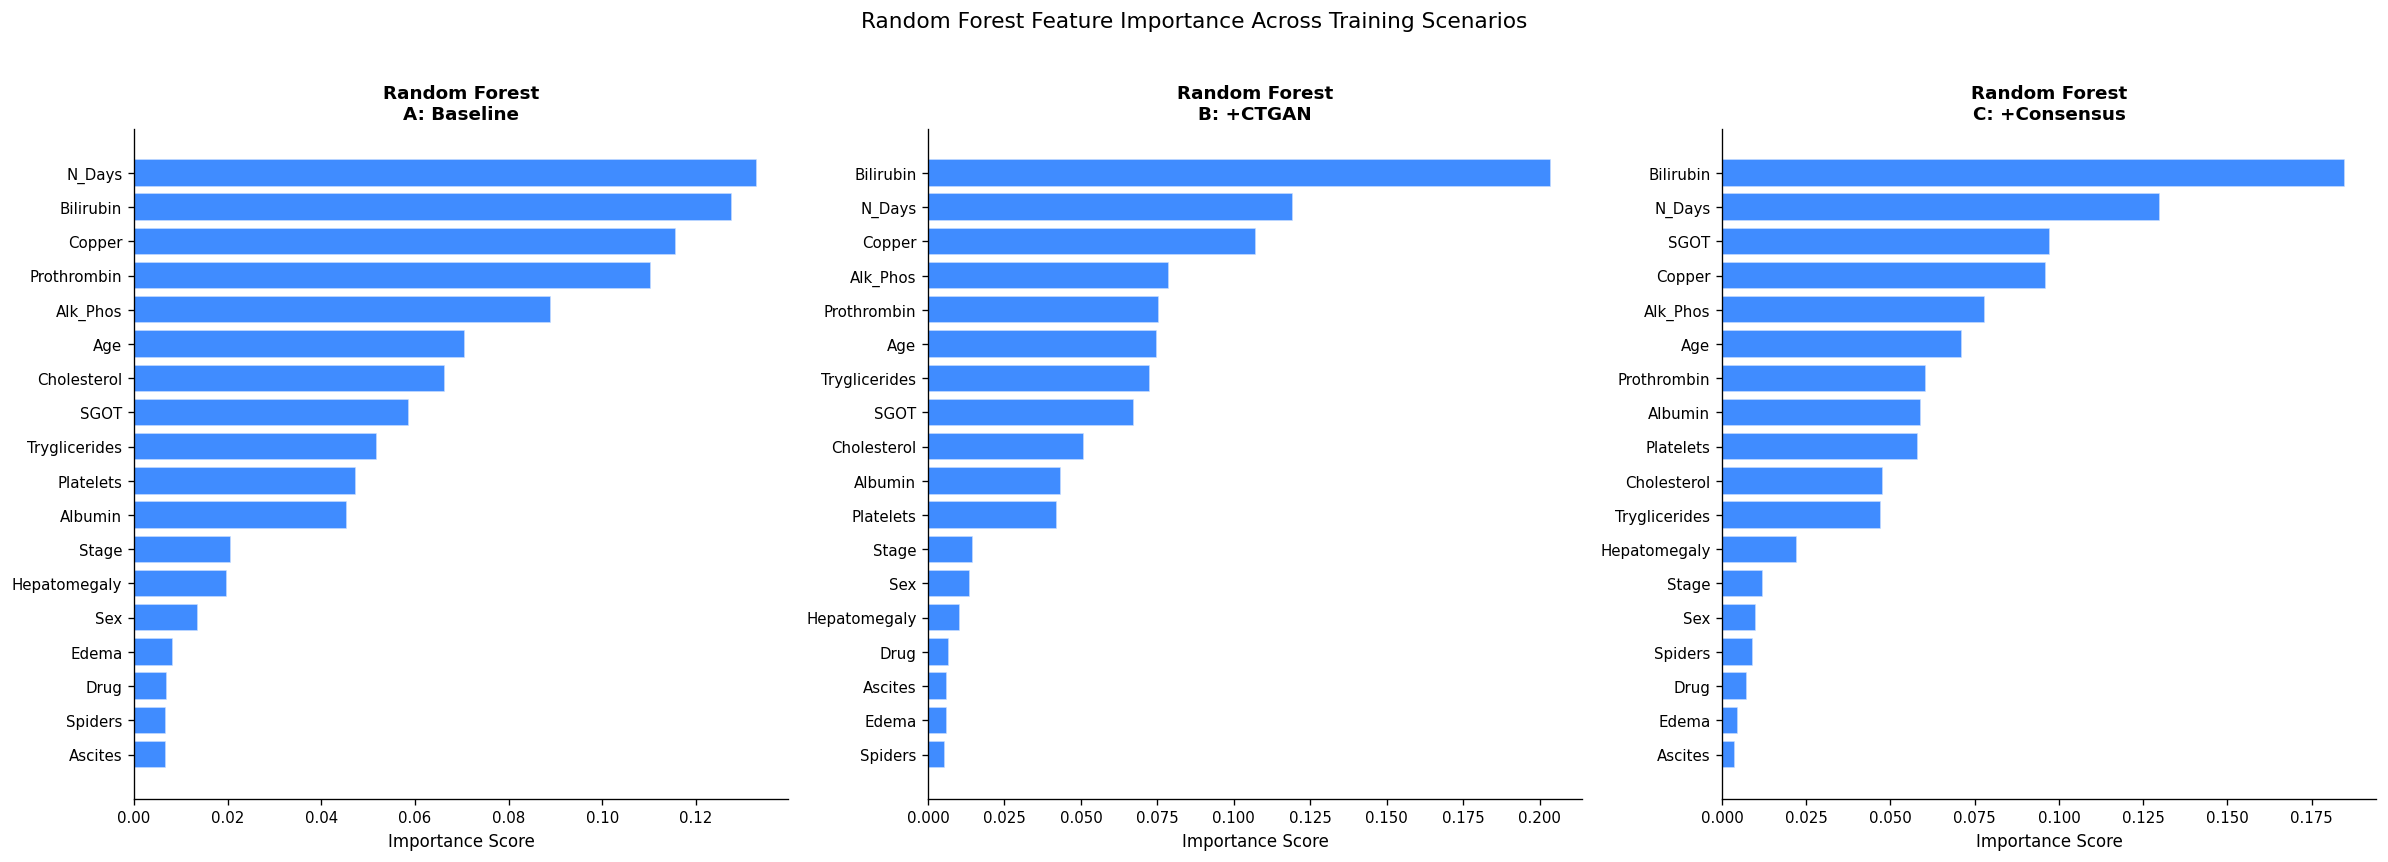

Feature importance by scenario saved to output/figures/feature_importance_by_scenario.png


In [28]:
# Feature importance across all three scenarios using Random Forest
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax_idx, (sc_name, short) in enumerate(zip(list(base_scenarios.keys()), SCEN_SHORT)):
    rf_m = trained_clf_objs[sc_name]['Random Forest']
    imp  = pd.Series(rf_m.feature_importances_, index=feat_cols_shared).sort_values(ascending=False)
    ax   = axes[ax_idx]
    ax.barh(imp.index[::-1], imp.values[::-1],
            color='#0066FF', alpha=0.75, edgecolor='white')
    ax.set_title(f'Random Forest\n{short}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Random Forest Feature Importance Across Training Scenarios',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('output/figures/feature_importance_by_scenario.png')
plt.show()
print('Feature importance by scenario saved to output/figures/feature_importance_by_scenario.png')

---

## Section 9: Output File Index

All files produced by the three notebooks are listed below for reference.

In [29]:
for root, dirs, files in os.walk('output'):
    dirs.sort()
    for fname in sorted(files):
        full_path = os.path.join(root, fname)
        size_kb   = os.path.getsize(full_path) / 1024
        print(f'  {full_path:<60}  {size_kb:6.1f} KB')

  output/.DS_Store                                                 6.0 KB
  output/data/complete_data.csv                                   20.7 KB
  output/data/consensus.csv                                      187.9 KB
  output/data/filtered_ctgan.csv                                  25.4 KB
  output/data/filtered_gan.csv                                    27.3 KB
  output/data/filtered_tvae.csv                                   60.6 KB
  output/data/scaler.pkl                                           1.5 KB
  output/data/synthetic_ctgan.csv                                 60.3 KB
  output/data/synthetic_gan.csv                                   60.3 KB
  output/data/synthetic_tvae.csv                                  60.6 KB
  output/data/test_real.csv                                        6.3 KB
  output/data/train_real.csv                                      14.5 KB
  output/figures/3d_bubble_biomarkers.png                       1479.9 KB
  output/figures/3d_clinical_biomarker

---

## End of Pipeline

All four notebooks have been completed. The full pipeline covers:

1. Exploratory data analysis — histograms, box plots, violin plots, pairplot, correlation matrix, outlier profile, and normality tests across all 18 clinical features
2. Data loading, missingness analysis, complete-case filtering, encoding, and stratified 70/30 split
3. Synthetic generation with Vanilla GAN, CTGAN, and TVAE — all implemented from scratch using TensorFlow
4. IQR-based outlier filtering to remove physiologically implausible synthetic records
5. Multi-method consensus voting to identify high-confidence synthetic records endorsed by all three generators
6. Tabular FID scoring to quantify distributional fidelity of each synthetic dataset
7. Five formal statistical tests — Shapiro-Wilk, KS, Jensen-Shannon divergence, Cohen's d, and chi-square
8. Predictive utility evaluation across three training scenarios and three classifiers on a held-out real test set
9. SMOTE baseline comparison to benchmark generative model augmentation against classical oversampling
10. 5-fold stratified cross-validation with AUC mean and standard deviation across all scenarios
11. Bootstrap confidence intervals (1 000 resamples) for AUC on the held-out test set
12. McNemar's exact test comparing classification errors between augmented and baseline scenarios
13. ROC curves for all scenario and classifier combinations
14. Precision-Recall curves for all scenario and classifier combinations
15. Feature importance rankings from Random Forest and Gradient Boosting across all training scenarios
16. Full plain-text summary report collecting all key results in one document

All outputs are in the `output/` directory.